Running Central Limit Theorem case...

--- Anderson-Darling Test (central-limit) ---
Statistic: 1.4225
Critical Values: [0.576 0.656 0.787 0.918 1.092]
Significance Levels: [15.  10.   5.   2.5  1. ]
Result: Data does NOT look Gaussian (Reject H0 at 5%)


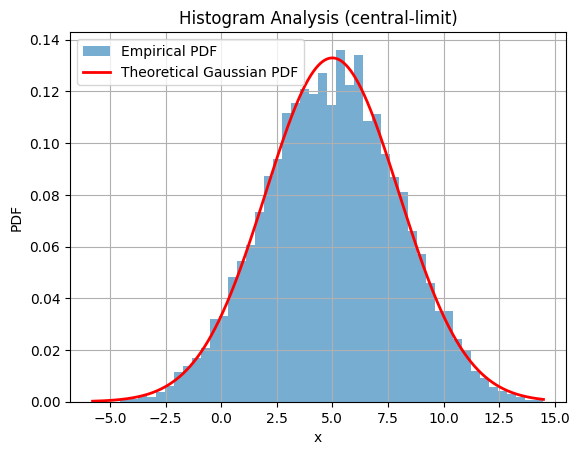

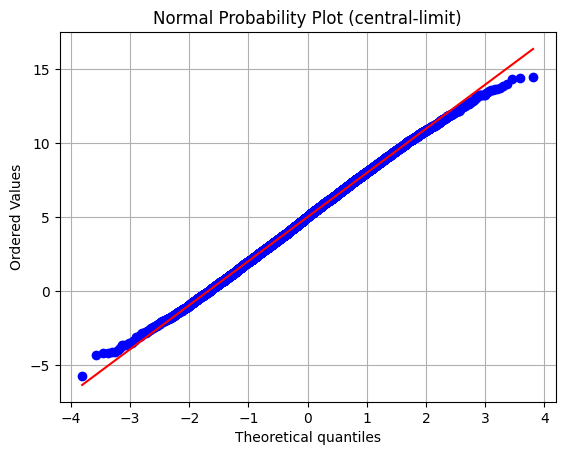

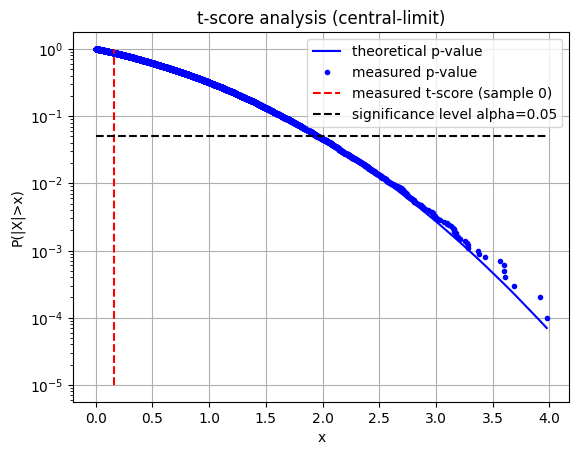

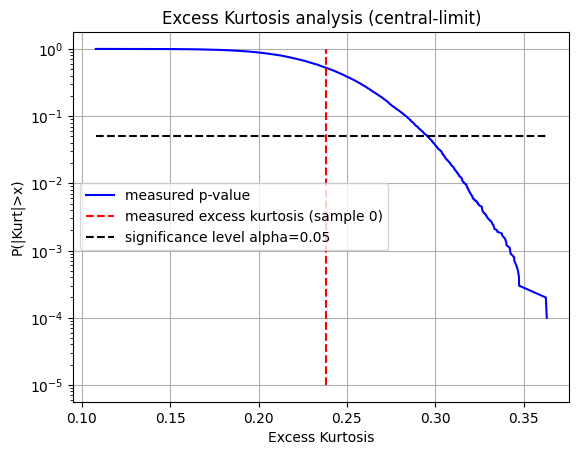

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import t

class GaussianityValidator:
    def __init__(self, n_samples, n_exp, mu, sigma, seed):
        """
        Class to handle Laboratory 6 Part 1: Gaussianity Tests.
        Refactored from central_limit.py while maintaining original logic.
        """
        self.Ns = n_samples      # Number of samples per experiment
        self.Nexp = n_exp        # Number of experiments (for p-value distribution)
        self.mu = mu             # Desired mean
        self.sigma = sigma       # Desired standard deviation
        self.seed = seed
        np.random.seed(self.seed) # set the seed to reproduce the experiment
        
        # Storage for results
        self.x = None            # Current sample batch
        self.valT = None         # t-scores from experiments
        self.valKurt = None      # Kurtosis values from experiments
        self.label = ""

    def run_simulation(self, case="central-limit"):
        """
        Runs the simulation Nexp times to collect statistics (t-score, kurtosis).
        original logic: generate samples using Box-Muller or CLT.
        """
        self.label = case
        
        # We generate (Nexp, Ns) matrix to perform all experiments at once (Vectorized logic)
        # or we can loop. Vectorized is closer to 'numpy style' logic of original scripts.
        
        if case == "central-limit":
            # Central limit theorem (approximate)
            N = 5 # number of independent uniform random variables
            K = self.sigma * np.sqrt(3)
            
            # 3D array: (Nexp, Ns, N) to sum across the last axis
            # uniformly distributed in -K,K (variance = sigma^2)
            xUnif = (np.random.rand(self.Nexp, self.Ns, N) - 0.5) * 2 * K 
            
            # generate x as approximately Gaussian:
            # apply formula of central limit and add the desired mean
            self.x_all = np.sum(xUnif, axis=2) / np.sqrt(N) + self.mu
            
        elif case == "Box-Muller":
            # Box-Muller (exact)
            u1 = np.random.rand(self.Nexp, self.Ns)
            u2 = np.random.rand(self.Nexp, self.Ns)
            # Apply transformation
            self.x_all = self.sigma * np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2) + self.mu
        
        # Store just the first experiment for the histogram plot
        self.x = self.x_all[0, :]

        # --- Compute Statistics for ALL experiments ---
        
        # 1. t-score calculation
        # t = (mean - mu) / (std / sqrt(Ns))
        means = np.mean(self.x_all, axis=1)
        stds = np.std(self.x_all, axis=1, ddof=1) # Unbiased std dev
        self.valT = (means - self.mu) / (stds / np.sqrt(self.Ns))
        
        # 2. Excess kurtosis calculation
        # Fisher kurtosis (should be 0 for Gaussian)
        self.valKurt = stats.kurtosis(self.x_all, axis=1, fisher=True)

    def plot_histogram(self):
        """1. Plotting the normalized histogram."""
        plt.figure()
        # normalized histogram
        count, bins, ignored = plt.hist(self.x, 50, density=True, alpha=0.6, label='Empirical PDF')
        
        # Theoretical Gaussian PDF
        # verify the mean and standard deviation of the obtained vector
        x_grid = np.linspace(min(bins), max(bins), 1000)
        pdf = 1/(self.sigma * np.sqrt(2 * np.pi)) * np.exp(-(x_grid - self.mu)**2 / (2 * self.sigma**2))
        plt.plot(x_grid, pdf, linewidth=2, color='r', label='Theoretical Gaussian PDF')
        
        plt.title(f'Histogram Analysis ({self.label})')
        plt.xlabel('x')
        plt.ylabel('PDF')
        plt.legend()
        plt.grid(True)
        # plt.show() # Commented to allow batch plotting

    def plot_npp(self):
        """2. Using the Normal Probability plot (a version of the Q-Q plot)."""
        plt.figure()
        # stats.probplot generates the plot against the normal distribution
        stats.probplot(self.x, dist="norm", plot=plt)
        plt.title(f'Normal Probability Plot ({self.label})')
        plt.grid(True)

    def plot_t_score_analysis(self):
        """
        Checks the distribution of the t-score p-values.
        Original logic: plots theoretical p-value vs measured p-value.
        """
        plt.figure()
        
        # Calculate p-values from t-scores
        # Logic from original: 2*(1-t.cdf(vals, Ns-1)) for two-tailed
        vals = np.sort(np.abs(self.valT))
        
        # Theoretical p-value line
        plt.plot(vals, 2 * (1 - t.cdf(vals, self.Ns - 1)), 'b', label='theoretical p-value')
        
        # Measured p-value (empirical CDF)
        # 1 - rank/N
        plt.plot(vals, 1 - np.arange(self.Nexp) / self.Nexp, 'b.', label='measured p-value')
        
        # Marker for a specific t-score (e.g., the last one computed)
        tx = self.valT[0]
        plt.semilogy([np.abs(tx), np.abs(tx)], [1e-5, 1], 'r--', label='measured t-score (sample 0)')
        
        # Significance level
        v1 = np.min(np.abs(self.valT))
        v2 = np.max(np.abs(self.valT))
        plt.semilogy([v1, v2], [0.05, 0.05], 'k--', label='significance level alpha=0.05')
        
        plt.grid()
        plt.xlabel('x')
        plt.ylabel('P(|X|>x)')
        plt.legend()
        plt.title(f't-score analysis ({self.label})')

    def plot_kurtosis_analysis(self):
        """
        Checks the distribution of the Excess Kurtosis.
        Original logic: plots measured p-value vs measured excess kurtosis.
        """
        plt.figure()
        
        # Sort kurtosis values
        vals_kurt = np.sort(np.abs(self.valKurt))
        
        # Measured p-value
        plt.semilogy(vals_kurt, 1 - np.arange(self.Nexp) / self.Nexp, 'b', label='measured p-value')
        
        # Marker for sample 0
        ku = self.valKurt[0]
        plt.semilogy([np.abs(ku), np.abs(ku)], [1e-5, 1], 'r--', label='measured excess kurtosis (sample 0)')
        
        # Significance level
        v1 = np.min(vals_kurt)
        v2 = np.max(vals_kurt)
        plt.semilogy([v1, v2], [0.05, 0.05], 'k--', label='significance level alpha=0.05')
        
        plt.grid()
        plt.xlabel('Excess Kurtosis')
        plt.ylabel('P(|Kurt|>x)')
        plt.legend()
        plt.title(f'Excess Kurtosis analysis ({self.label})')

    def run_anderson_darling(self):
        """4. Using Anderson-Darling test and finding the p-value."""
        print(f"\n--- Anderson-Darling Test ({self.label}) ---")
        # ad_stat: Anderson-Darling statistic
        # ad_crit: critical values
        # ad_sig: significance levels
        ad_stat, ad_crit, ad_sig = stats.anderson(self.x, dist='norm')
        
        print(f"Statistic: {ad_stat:.4f}")
        print(f"Critical Values: {ad_crit}")
        print(f"Significance Levels: {ad_sig}")
        
        # Check at 5% significance (index 2 usually corresponds to 5% in scipy output)
        if ad_stat < ad_crit[2]:
            print("Result: Data looks Gaussian (Fail to reject H0 at 5%)")
        else:
            print("Result: Data does NOT look Gaussian (Reject H0 at 5%)")


if __name__ == "__main__":
    
    # Case 1: Central Limit
    print("Running Central Limit Theorem case...")
    validator = GaussianityValidator(n_samples=10000, n_exp=10000, mu=5, sigma=3, seed=360457)
    validator.run_simulation(case="central-limit")
    
    validator.plot_histogram()
    validator.plot_npp()
    validator.plot_t_score_analysis()
    validator.plot_kurtosis_analysis()
    validator.run_anderson_darling()
    
    # Optional: Case 2 Box-Muller (can be uncommented)
    # print("\nRunning Box-Muller case...")
    # validator.run_simulation(case="Box-Muller")
    # validator.plot_histogram()
    
    plt.show()